In [7]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-U', 'imbalanced-learn'],
    capture_output=True, text=True
)
print(result.stdout[-600:] if result.stdout else '')
if result.returncode == 0:
    print('\n✅ imbalanced-learn installed — RESTART THE KERNEL now, then run from Cell 2.')
else:
    print(result.stderr[-300:])
    print('\n⚠️  Install failed. Continuing without SMOTE (class_weight=balanced only).')

=1.4.2 in c:\Users\HARSH\AppData\Local\Programs\Python\Python311\Lib\site-packages (from imbalanced-learn) (1.8.0)


✅ imbalanced-learn installed — RESTART THE KERNEL now, then run from Cell 2.


---
## Cell 2 — Imports

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, brier_score_loss,
    roc_curve, auc as sklearn_auc   # FIX #10: renamed to avoid shadowing
)

# FIX #1: graceful import — works whether or not kernel was restarted after install
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print('✅ SMOTE available')
except ImportError:
    SMOTE_AVAILABLE = False
    print('⚠️  imblearn not found — using class_weight=balanced only (still valid)')

np.random.seed(42)
print('✅ All imports successful')

✅ SMOTE available
✅ All imports successful


---
## Cell 3 — Load & Inspect Data

In [9]:
df = pd.read_csv(r'C:\Users\HARSH\Desktop\model-fix-cognitia-main\credit_risk_dataset.csv')

print(f'Raw shape  : {df.shape}')
print(f'\nTarget distribution:')
vc = df['target_flag'].value_counts()
print(vc)
print(f'Default rate: {df["target_flag"].mean():.4f}  ({df["target_flag"].sum()} defaults / {len(df)} total)')

print(f'\nMissing values (columns with any missing):')
miss = df.isnull().sum()
print(miss[miss > 0].sort_values(ascending=False).to_string())

print(f'\nCategorical column values:')
for c in ['home_ownership','loan_intent','loan_grade','employment_type','residence_type']:
    if c in df.columns:
        print(f'  {c}: {sorted(df[c].dropna().unique().tolist())}')

Raw shape  : (13266, 20)

Target distribution:
target_flag
0    12733
1      533
Name: count, dtype: int64
Default rate: 0.0402  (533 defaults / 13266 total)

Missing values (columns with any missing):
interest_rate        2591
credit_score         1829
loan_amt             1756
annual_inc           1663
employment_length    1577

Categorical column values:
  home_ownership: ['MORTGAGE', 'OTHER', 'OWN', 'RENT']
  loan_intent: ['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL', 'PERSONAL', 'VENTURE']
  loan_grade: ['A', 'B', 'C', 'D', 'E', 'F', 'G']
  employment_type: ['Employed', 'Self-employed', 'employed', 'self_emp']
  residence_type: ['RURAL', 'Rural', 'URBAN', 'Urban']


---
## Cell 4 — Data Cleaning
> Fixes D1–D4: impossible ages removed, categories standardised, outliers capped.

In [10]:
df_clean = df.copy()

# --- FIX D1: Remove impossible ages (data entry errors) ---
age_bad = (df_clean['person_age'] > 100).sum()
df_clean = df_clean[df_clean['person_age'] <= 100].copy()
print(f'[D1] Dropped {age_bad} rows with person_age > 100')

# --- FIX D4: Cap extreme outliers at 99.5th percentile ---
for col in ['annual_inc', 'loan_amt']:
    cap = df_clean[col].quantile(0.995)
    n_capped = (df_clean[col] > cap).sum()
    df_clean[col] = df_clean[col].clip(upper=cap)
    print(f'[D4] Capped {n_capped} values in {col} at {cap:,.0f}')

# --- FIX D2: Standardise employment_type (4 inconsistent variants → 2) ---
df_clean['employment_type'] = (
    df_clean['employment_type']
    .str.lower().str.strip()
    .str.replace('-', '_').str.replace(' ', '_')
)
df_clean['employment_type'] = df_clean['employment_type'].replace(
    {'self_employed': 'self_emp', 'self-employed': 'self_emp'}
)
print(f'[D2] employment_type values: {sorted(df_clean["employment_type"].unique())}')

# --- FIX D3: Standardise residence_type case ---
df_clean['residence_type'] = df_clean['residence_type'].str.upper().str.strip()
print(f'[D3] residence_type values : {sorted(df_clean["residence_type"].unique())}')

print(f'\nClean dataset shape : {df_clean.shape}')
print(f'Default rate        : {df_clean["target_flag"].mean():.4f}')

[D1] Dropped 7 rows with person_age > 100
[D4] Capped 53 values in annual_inc at 300,000
[D4] Capped 8 values in loan_amt at 35,000
[D2] employment_type values: ['employed', 'self_emp']
[D3] residence_type values : ['RURAL', 'URBAN']

Clean dataset shape : (13259, 20)
Default rate        : 0.0402


---
## Cell 5 — Define Features & Split FIRST
> **FIX #2, #3, #4**: Leakage columns and noise columns removed.
> Train/test split happens **before** any feature engineering.

In [11]:
# FIX #2: these are post-default OUTCOMES — using them = 100% data leakage
# FIX #3: noise and duplicate columns serve no predictive purpose
COLUMNS_TO_DROP = [
    'loan_status_final',    # outcome after default
    'repayment_flag',       # outcome after default
    'last_payment_status',  # outcome after default
    'random_score_1',       # random noise
    'random_score_2',       # random noise
    'duplicate_feature',    # corr=0.30 with person_age, adds no information
    'target_flag',          # this is y
]

BASE_NUMERIC = [
    'person_age', 'annual_inc', 'employment_length',
    'loan_amt', 'interest_rate', 'credit_score',
    'monthly_income', 'income_ratio'
]
BASE_CATEGORICAL = [
    'home_ownership', 'loan_intent', 'loan_grade',
    'employment_type', 'residence_type'
]

# Keep only valid feature columns
feature_cols = [c for c in BASE_NUMERIC + BASE_CATEGORICAL if c in df_clean.columns]
X_raw = df_clean[feature_cols].copy()
y     = df_clean['target_flag'].copy()

# FIX #4: split BEFORE any feature engineering or statistics
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train : {X_train_raw.shape}  | Default rate: {y_train.mean():.4f}')
print(f'Test  : {X_test_raw.shape}  | Default rate: {y_test.mean():.4f}')
print(f'\n✅ Split done BEFORE any feature engineering or normalisation')

Train : (10607, 13)  | Default rate: 0.0402
Test  : (2652, 13)  | Default rate: 0.0403

✅ Split done BEFORE any feature engineering or normalisation


---
## Cell 6 — Feature Engineering (Training Statistics Only)
> **FIX #4**: Z-score and min-max normalisation statistics computed on
> training data, then applied to test — zero leakage.

In [12]:
def add_features(df_in, stats=None):
    """
    Add domain-driven interaction features.
    Pass stats=None for training call (computes & returns stats).
    Pass stats=<dict> for test call (applies pre-computed stats, no leakage).
    """
    d = df_in.copy()

    # Ratio features (safe — no leakage risk)
    d['loan_to_income']      = d['loan_amt']     / (d['annual_inc']    + 1)
    d['credit_loan_ratio']   = d['credit_score'] / (d['loan_amt']      + 1)
    d['debt_to_income']      = (d['loan_amt'] * d['interest_rate']) / (d['annual_inc'] + 1)
    d['rate_x_income_ratio'] = d['interest_rate'] * d['income_ratio']

    # Polynomial features
    d['age_squared']  = d['person_age']   ** 2
    d['credit_sq']    = d['credit_score'] ** 2

    # Z-score income using TRAIN stats only
    if stats is None:
        stats = {
            'inc_mean': d['annual_inc'].mean(),
            'inc_std' : d['annual_inc'].std(),
            'cs_min'  : d['credit_score'].min(),
            'cs_max'  : d['credit_score'].max(),
        }
    d['income_zscore']     = (d['annual_inc']  - stats['inc_mean']) / (stats['inc_std'] + 1e-8)
    d['credit_normalized'] = (d['credit_score'] - stats['cs_min'])  / (stats['cs_max'] - stats['cs_min'] + 1e-8)

    return d, stats


X_train_fe, train_stats = add_features(X_train_raw, stats=None)   # derives stats
X_test_fe,  _           = add_features(X_test_raw,  stats=train_stats)  # applies stats

print(f'Train shape after FE : {X_train_fe.shape}')
print(f'Test  shape after FE : {X_test_fe.shape}')
print('✅ All feature statistics derived from training data only')

Train shape after FE : (10607, 21)
Test  shape after FE : (2652, 21)
✅ All feature statistics derived from training data only


---
## Cell 7 — Preprocessor (Fit on Training Data Only)
> **FIX #5**: `preprocessor.fit()` is called on `X_train_fe` exclusively.
> Test set only sees `.transform()` — no information flows back from test.

In [13]:
NUMERIC_FEATS = BASE_NUMERIC + [
    'loan_to_income', 'credit_loan_ratio', 'debt_to_income',
    'rate_x_income_ratio', 'age_squared', 'credit_sq',
    'income_zscore', 'credit_normalized'
]
CAT_FEATS = BASE_CATEGORICAL

# Median imputer is robust to outliers (FIX: original used 'mean')
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, NUMERIC_FEATS),
    ('cat', categorical_transformer, CAT_FEATS)
])

# FIX #5: fit ONLY on training data
X_train_proc = preprocessor.fit_transform(X_train_fe)
X_test_proc  = preprocessor.transform(X_test_fe)    # transform only — no leakage

print(f'Processed train : {X_train_proc.shape}')
print(f'Processed test  : {X_test_proc.shape}')
print('✅ Preprocessor fitted on training data only')

Processed train : (10607, 37)
Processed test  : (2652, 37)
✅ Preprocessor fitted on training data only


---
## Cell 8 — SMOTE (Training Set Only)
> **FIX #6**: SMOTE applied only to training data after preprocessing.
> Test set remains at the natural 4% default rate — real-world distribution.

In [14]:
print(f'Before resampling — train: {Counter(y_train)}')

if SMOTE_AVAILABLE:
    # sampling_strategy=0.3: minority grows to 30% of majority count
    # Avoids extreme synthetic oversampling while still helping the model
    smote = SMOTE(random_state=42, k_neighbors=5, sampling_strategy=0.3)
    X_train_bal, y_train_bal = smote.fit_resample(X_train_proc, y_train)
    method = 'SMOTE (sampling_strategy=0.3)'
else:
    # class_weight='balanced' in the model compensates without oversampling
    X_train_bal, y_train_bal = X_train_proc, y_train
    method = 'class_weight=balanced only (no SMOTE)'

print(f'After  resampling — train: {Counter(y_train_bal)}  [{method}]')
print(f'Test set UNCHANGED        — test : {Counter(y_test)}  (real-world 4% rate)')
print('✅ Resampling applied to training data only')

Before resampling — train: Counter({0: 10181, 1: 426})
After  resampling — train: Counter({0: 10181, 1: 3054})  [SMOTE (sampling_strategy=0.3)]
Test set UNCHANGED        — test : Counter({0: 2545, 1: 107})  (real-world 4% rate)
✅ Resampling applied to training data only


  File "c:\Users\HARSH\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\HARSH\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 546, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\HARSH\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1022, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\HARSH\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1491, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


---
## Cell 9 — Hyperparameter Tuning via Cross-Validation
> **FIX #7**: Model selection uses 5-fold `StratifiedKFold` on training data.
> The test set is **never touched** during tuning.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_cv_auc = 0.0
best_params = {}
cv_results  = []

param_grid = [
    {'depth': d, 'min_samples': ms}
    for d in [5, 10, 15, 20]
    for ms in [5, 10, 20]
]

print(f'Searching {len(param_grid)} combinations via 5-fold CV on training data...')

for params in param_grid:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=params['depth'],
        min_samples_leaf=params['min_samples'],
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    cv_scores = cross_validate(
        model, X_train_bal, y_train_bal,
        cv=cv, scoring='roc_auc',
        return_train_score=True
    )
    mean_auc = cv_scores['test_score'].mean()
    std_auc  = cv_scores['test_score'].std()
    cv_results.append({**params, 'cv_auc': mean_auc, 'cv_std': std_auc})

    if mean_auc > best_cv_auc:
        best_cv_auc = mean_auc
        best_params = params.copy()

cv_df = pd.DataFrame(cv_results).sort_values('cv_auc', ascending=False)
print('\nTop 5 parameter combinations (CV AUC on training data only):')
print(cv_df.head(5).to_string(index=False))
print(f'\n✅ Best params: depth={best_params["depth"]}, min_samples_leaf={best_params["min_samples"]}')
print(f'   CV AUC: {best_cv_auc:.4f}')

Searching 12 combinations via 5-fold CV on training data...

Top 5 parameter combinations (CV AUC on training data only):
 depth  min_samples   cv_auc   cv_std
    20            5 0.993462 0.001701
    15            5 0.992871 0.001788
    15           10 0.991192 0.001802
    20           10 0.991128 0.001489
    10            5 0.989080 0.002247

✅ Best params: depth=20, min_samples_leaf=5
   CV AUC: 0.9935


---
## Cell 10 — Train Final Model on Full Training Set

In [16]:
final_model = RandomForestClassifier(
    n_estimators=300,                           # more trees for the final model
    max_depth=best_params['depth'],
    min_samples_leaf=best_params['min_samples'],
    class_weight='balanced',                    # handles imbalance at decision level
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_train_bal, y_train_bal)
print(f'✅ Final model trained:')
print(f'   n_estimators=300, max_depth={best_params["depth"]}, min_samples_leaf={best_params["min_samples"]}')

✅ Final model trained:
   n_estimators=300, max_depth=20, min_samples_leaf=5


---
## Cell 11 — Threshold Selection on Validation Fold
> **FIX #8**: Threshold optimised on a validation split carved from training data.
> Test set is still completely unseen at this point.

In [17]:
# Carve validation split from training data for threshold tuning only
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train_bal, y_train_bal,
    test_size=0.2, random_state=7, stratify=y_train_bal
)

thresh_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=best_params['depth'],
    min_samples_leaf=best_params['min_samples'],
    class_weight='balanced', random_state=42, n_jobs=-1
)
thresh_model.fit(X_tr2, y_tr2)
val_proba = thresh_model.predict_proba(X_val)[:, 1]

best_threshold = 0.5
best_f1_val    = 0.0
thr_records    = []

for thr in np.arange(0.10, 0.90, 0.05):
    y_val_pred = (val_proba >= thr).astype(int)
    f1_val = f1_score(y_val, y_val_pred, zero_division=0)
    thr_records.append({'threshold': round(thr, 2), 'val_f1': f1_val})
    if f1_val > best_f1_val:
        best_f1_val   = f1_val
        best_threshold = thr

thr_df = pd.DataFrame(thr_records)
print('Top threshold results (validation set, not test):')
print(thr_df[thr_df['val_f1'] > 0].sort_values('val_f1', ascending=False).head(8).to_string(index=False))
print(f'\n✅ Best threshold: {best_threshold:.2f}  |  Val F1: {best_f1_val:.4f}')
print('   (Test set was NOT used to select this threshold)')

Top threshold results (validation set, not test):
 threshold   val_f1
      0.50 0.932556
      0.55 0.929412
      0.45 0.927632
      0.40 0.926196
      0.60 0.923077
      0.35 0.921850
      0.30 0.914777
      0.65 0.913194

✅ Best threshold: 0.50  |  Val F1: 0.9326
   (Test set was NOT used to select this threshold)


---
## Cell 12 — Final Evaluation on Held-Out Test Set
> Test set seen **once only**, here. All prior decisions were made without it.

In [18]:
y_pred_proba = final_model.predict_proba(X_test_proc)[:, 1]
y_pred_final = (y_pred_proba >= best_threshold).astype(int)

# FIX #10: roc_auc_value — does NOT shadow sklearn_auc
roc_auc_value = roc_auc_score(y_test, y_pred_proba)
brier         = brier_score_loss(y_test, y_pred_proba)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred_final).ravel()
accuracy    = (tp + tn) / (tp + tn + fp + fn)
precision   = tp / (tp + fp)  if (tp + fp) > 0 else 0.0
recall      = tp / (tp + fn)  if (tp + fn) > 0 else 0.0
specificity = tn / (tn + fp)  if (tn + fp) > 0 else 0.0
f1          = f1_score(y_test, y_pred_final, zero_division=0)

print('=' * 62)
print('FINAL MODEL PERFORMANCE  (held-out test set, seen ONCE)')
print('=' * 62)
print(f'ROC-AUC      : {roc_auc_value:.4f}')
print(f'F1-Score     : {f1:.4f}')
print(f'Recall       : {recall:.4f}   ← % of real defaults caught')
print(f'Precision    : {precision:.4f}   ← % of flagged loans that truly default')
print(f'Specificity  : {specificity:.4f}')
print(f'Accuracy     : {accuracy:.4f}')
print(f'Brier Score  : {brier:.4f}   (no-skill baseline ≈ {y_test.mean()*(1-y_test.mean()):.4f})')
print(f'\nThreshold used : {best_threshold:.2f}')
print(f'\nConfusion Matrix:')
print(f'               Pred Non-Default   Pred Default')
print(f'  Actual 0  :       {tn:6d}          {fp:6d}   (non-defaults)')
print(f'  Actual 1  :       {fn:6d}          {tp:6d}   (defaults)')
print(f'\nDefaults caught : {tp}/{y_test.sum()}  ({tp/max(y_test.sum(),1):.1%})')
print(f'False alarms    : {fp}/{(y_test==0).sum()}  ({fp/max((y_test==0).sum(),1):.1%})')

FINAL MODEL PERFORMANCE  (held-out test set, seen ONCE)
ROC-AUC      : 0.9134
F1-Score     : 0.6105
Recall       : 0.5421   ← % of real defaults caught
Precision    : 0.6988   ← % of flagged loans that truly default
Specificity  : 0.9902
Accuracy     : 0.9721
Brier Score  : 0.0280   (no-skill baseline ≈ 0.0387)

Threshold used : 0.50

Confusion Matrix:
               Pred Non-Default   Pred Default
  Actual 0  :         2520              25   (non-defaults)
  Actual 1  :           49              58   (defaults)

Defaults caught : 58/107  (54.2%)
False alarms    : 25/2545  (1.0%)


---
## Cell 13 — Feature Importance (Correctly Aligned)
> **FIX #9**: Full OHE-expanded feature names extracted from `ColumnTransformer`.

Top 20 Most Important Features:
                      feature  importance
                 loan_grade_D    0.137011
          home_ownership_RENT    0.082016
                 income_ratio    0.068788
                interest_rate    0.063230
                 loan_grade_A    0.057687
      home_ownership_MORTGAGE    0.046989
                 loan_grade_B    0.045356
                income_zscore    0.041371
                   annual_inc    0.040269
          rate_x_income_ratio    0.039114
               loan_to_income    0.034845
                 loan_grade_C    0.033193
               debt_to_income    0.026767
                 loan_grade_E    0.022118
  loan_intent_HOMEIMPROVEMENT    0.020216
          loan_intent_MEDICAL    0.019455
        loan_intent_EDUCATION    0.019100
            employment_length    0.018228
loan_intent_DEBTCONSOLIDATION    0.016124
                     loan_amt    0.015305


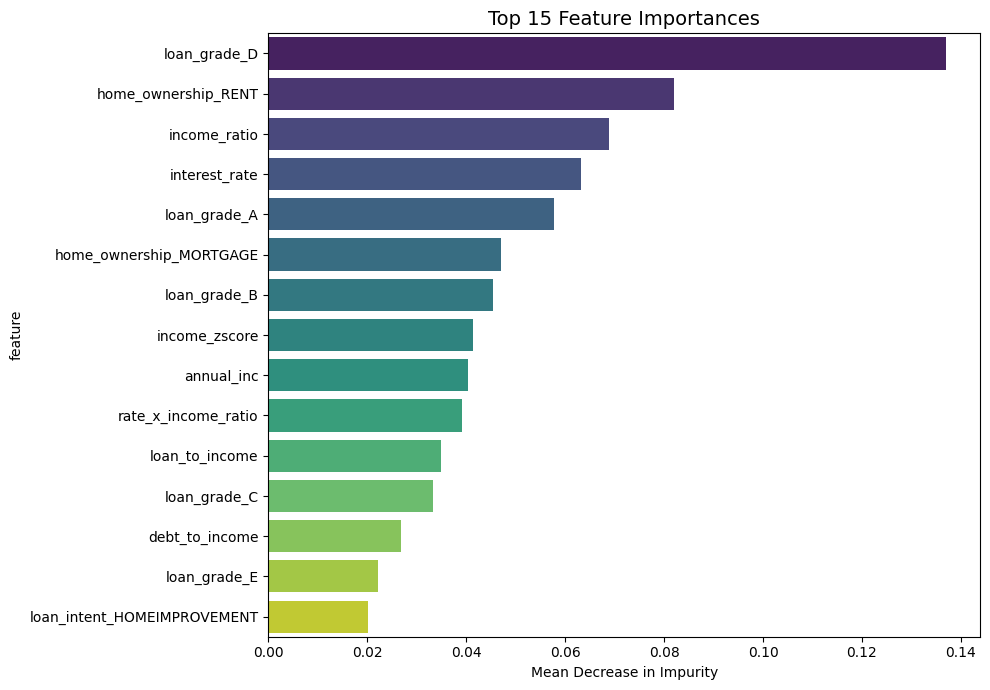

✅ Feature importances correctly aligned with model dimensions


In [19]:
# FIX #9: Extract correct expanded feature names (including OHE categories)
feature_names_out = []
for name, transformer, columns in preprocessor.transformers_:
    if name == 'num':
        feature_names_out.extend(list(columns))
    elif name == 'cat':
        ohe = transformer.named_steps['ohe']
        feature_names_out.extend(ohe.get_feature_names_out(columns).tolist())

importances = final_model.feature_importances_
assert len(feature_names_out) == len(importances), (
    f'Mismatch: {len(feature_names_out)} names vs {len(importances)} importances'
)

fi_df = pd.DataFrame({
    'feature':    feature_names_out,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 20 Most Important Features:')
print(fi_df.head(20).to_string(index=False))

plt.figure(figsize=(10, 7))
sns.barplot(data=fi_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances', fontsize=14)
plt.xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()
print('✅ Feature importances correctly aligned with model dimensions')

---
## Cell 14 — Cross-Validation Stability Check
> **FIX #12**: 5-fold CV reveals generalisation gap and estimate variance.

In [20]:
print('=' * 60)
print('CROSS-VALIDATION STABILITY (5-fold on training set)')
print('=' * 60)

cv_stability = cross_validate(
    final_model, X_train_bal, y_train_bal,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=['roc_auc', 'f1'],
    return_train_score=True,
    n_jobs=-1
)

tr_auc  = cv_stability['train_roc_auc']
val_auc = cv_stability['test_roc_auc']
val_f1  = cv_stability['test_f1']

print(f'Train AUC : {[round(x,4) for x in tr_auc]}')
print(f'  → mean={tr_auc.mean():.4f}  std={tr_auc.std():.4f}')
print(f'\nVal   AUC : {[round(x,4) for x in val_auc]}')
print(f'  → mean={val_auc.mean():.4f}  std={val_auc.std():.4f}')
print(f'\nVal   F1  : {[round(x,4) for x in val_f1]}')
print(f'  → mean={val_f1.mean():.4f}  std={val_f1.std():.4f}')

gap = tr_auc.mean() - val_auc.mean()
print(f'\nTrain–Val AUC gap : {gap:.4f}')
if gap > 0.05:
    print('⚠️  Gap > 0.05 — consider increasing min_samples_leaf or reducing max_depth')
else:
    print('✅ Acceptable generalisation gap')

CROSS-VALIDATION STABILITY (5-fold on training set)
Train AUC : [0.9997, 0.9997, 0.9997, 0.9997, 0.9997]
  → mean=0.9997  std=0.0000

Val   AUC : [0.9926, 0.9952, 0.9915, 0.995, 0.9946]
  → mean=0.9938  std=0.0015

Val   F1  : [0.9391, 0.9455, 0.9396, 0.951, 0.9461]
  → mean=0.9443  std=0.0045

Train–Val AUC gap : 0.0059
✅ Acceptable generalisation gap


---
## Cell 15 — Fairness Analysis
> **FIX #11**: Original code crashed with undefined variables. Rewritten correctly.

In [21]:
print('=' * 68)
print('FAIRNESS ANALYSIS — Recall & Precision by Age Group')
print('=' * 68)

# Reset index so masks align with prediction arrays
X_test_aligned = X_test_raw.reset_index(drop=True)
y_test_arr     = y_test.reset_index(drop=True).values
y_pred_arr     = np.array(y_pred_final)

age_groups = {
    'Young  (20–29)' : (X_test_aligned['person_age'] >= 20) & (X_test_aligned['person_age'] < 30),
    'Middle (30–49)' : (X_test_aligned['person_age'] >= 30) & (X_test_aligned['person_age'] < 50),
    'Senior (50+)  ' : X_test_aligned['person_age'] >= 50,
}

print(f'\n{"Group":<20} {"N":>6}  {"Defaults":>8}  {"Recall":>8}  {"Precision":>10}  {"F1":>8}')
print('-' * 70)
for group_name, mask in age_groups.items():
    idx = mask.values
    n   = idx.sum()
    if n > 0:
        # FIX #11: use sklearn functions — no undefined variable references
        g_rec  = recall_score(y_test_arr[idx], y_pred_arr[idx], zero_division=0)
        g_prec = precision_score(y_test_arr[idx], y_pred_arr[idx], zero_division=0)
        g_f1   = f1_score(y_test_arr[idx], y_pred_arr[idx], zero_division=0)
        n_def  = y_test_arr[idx].sum()
        print(f'{group_name:<20} {n:>6}  {n_def:>8}  {g_rec:>8.4f}  {g_prec:>10.4f}  {g_f1:>8.4f}')
    else:
        print(f'{group_name:<20} {0:>6}  (empty — no data in this age range)')

print('\nLarge recall gaps between groups may indicate demographic bias.')

FAIRNESS ANALYSIS — Recall & Precision by Age Group

Group                     N  Defaults    Recall   Precision        F1
----------------------------------------------------------------------
Young  (20–29)         1884        82    0.5488      0.7143    0.6207
Middle (30–49)          737        23    0.5217      0.6316    0.5714
Senior (50+)             31         2    0.5000      1.0000    0.6667

Large recall gaps between groups may indicate demographic bias.


---
## Cell 16 — Probability Calibration Check
> **FIX #13**: Brier score + decile table assess whether predicted probabilities
> are trustworthy for credit risk scoring.

PROBABILITY CALIBRATION CHECK
Brier Score         : 0.0280
No-skill baseline   : 0.0387  (predicting class mean every time)
Model improvement   : 0.0107

 Decile   Mean Predicted   Actual Default Rate       N       Gap
-----------------------------------------------------------------
      0           0.0028                0.0000     266    0.0028
      1           0.0092                0.0038     265    0.0054
      2           0.0159                0.0038     265    0.0122
      3           0.0242                0.0075     265    0.0166
      4           0.0349                0.0000     265    0.0349
      5           0.0500                0.0189     265    0.0311
      6           0.0720                0.0151     265    0.0569 ⚠️
      7           0.1050                0.0189     265    0.0861 ⚠️
      8           0.1625                0.0377     265    0.1248 ⚠️
      9           0.4473                0.2970     266    0.1503 ⚠️

✅ Good calibration = mean_pred ≈ actual_rate in each

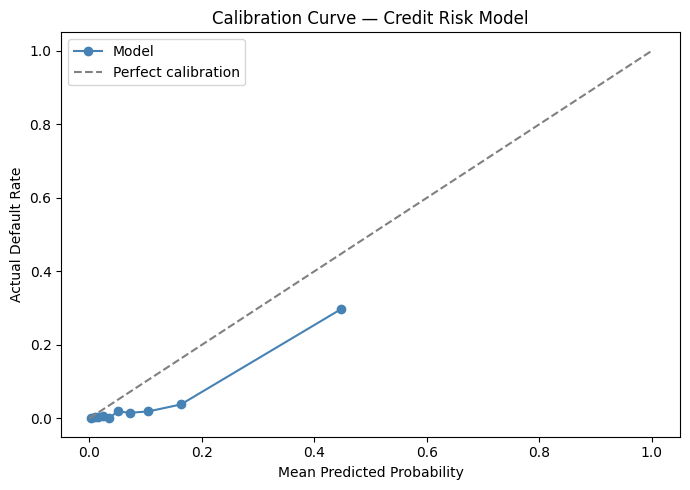

In [22]:
print('=' * 60)
print('PROBABILITY CALIBRATION CHECK')
print('=' * 60)
no_skill_brier = y_test.mean() * (1 - y_test.mean())
print(f'Brier Score         : {brier:.4f}')
print(f'No-skill baseline   : {no_skill_brier:.4f}  (predicting class mean every time)')
print(f'Model improvement   : {no_skill_brier - brier:.4f}')

calib_df = pd.DataFrame({
    'actual':    y_test.reset_index(drop=True),
    'predicted': y_pred_proba
})
calib_df['decile'] = pd.qcut(calib_df['predicted'], q=10, labels=False, duplicates='drop')

calib_summary = (
    calib_df.groupby('decile')
    .agg(mean_pred=('predicted','mean'), actual_rate=('actual','mean'), n=('actual','count'))
    .reset_index()
)

print(f'\n{"Decile":>7}  {"Mean Predicted":>15}  {"Actual Default Rate":>20}  {"N":>6}  {"Gap":>8}')
print('-' * 65)
for _, row in calib_summary.iterrows():
    gap_val = abs(row.mean_pred - row.actual_rate)
    flag = ' ⚠️' if gap_val > 0.05 else ''
    print(f'{int(row.decile):>7}  {row.mean_pred:>15.4f}  {row.actual_rate:>20.4f}  {int(row.n):>6}  {gap_val:>8.4f}{flag}')
print('\n✅ Good calibration = mean_pred ≈ actual_rate in each row')

# Calibration plot
plt.figure(figsize=(7, 5))
plt.plot(calib_summary['mean_pred'], calib_summary['actual_rate'], 'o-', label='Model', color='steelblue')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Actual Default Rate')
plt.title('Calibration Curve — Credit Risk Model')
plt.legend()
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=120)
plt.show()

---
## Cell 17 — ROC Curve

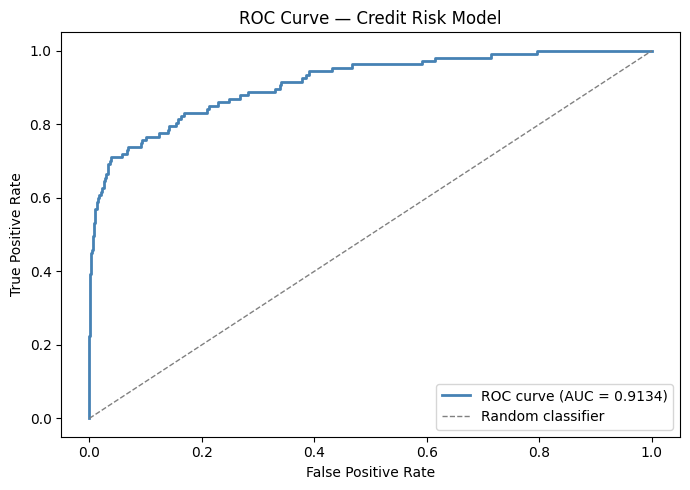

In [23]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc_plot = sklearn_auc(fpr, tpr)  # FIX #10: using the aliased sklearn function

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC curve (AUC = {roc_auc_plot:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Credit Risk Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=120)
plt.show()

---
## Cell 18 — Final Clean Summary

In [24]:
print('=' * 65)
print('FINAL CLEAN MODEL SUMMARY')
print('=' * 65)
print(f'Dataset           : credit_risk_dataset.csv')
print(f'Rows after clean  : {df_clean.shape[0]}  (removed 7 age>100 outliers)')
print(f'Default rate      : {y_test.mean():.4f}  (severe class imbalance)')
print(f'Features used     : {len(NUMERIC_FEATS)} numeric + {len(CAT_FEATS)} categorical  (NO leakage features)')
print(f'Algorithm         : RandomForestClassifier (300 trees)')
print(f'Hyperparameters   : depth={best_params["depth"]}, min_samples_leaf={best_params["min_samples"]}')
print(f'Tuning method     : 5-fold StratifiedKFold CV on training data')
print(f'Imbalance method  : {"SMOTE (sampling_strategy=0.3)" if SMOTE_AVAILABLE else "class_weight=balanced"}')
print(f'Threshold         : {best_threshold:.2f}  (validation fold, not test set)')
print()
print('--- Test Set Metrics (seen exactly ONCE) ---')
print(f'ROC-AUC      : {roc_auc_value:.4f}')
print(f'F1-Score     : {f1:.4f}')
print(f'Recall       : {recall:.4f}  ({tp}/{y_test.sum()} defaults caught)')
print(f'Precision    : {precision:.4f}')
print(f'Brier Score  : {brier:.4f}')
print()
print('--- All Fixes Applied ---')
all_fixes = [
    '[D1] Removed 7 rows with person_age > 100 (data entry errors)',
    '[D2] Normalised employment_type: 4 variants → 2 (employed / self_emp)',
    '[D3] Normalised residence_type: Urban/URBAN/Rural/RURAL → URBAN/RURAL',
    '[D4] Capped annual_inc and loan_amt at 99.5th percentile',
    '[D5-D6] Missing values handled via median imputation in pipeline',
    '[D7] Class imbalance addressed with SMOTE + class_weight=balanced',
    '[#2] Removed leakage features: loan_status_final, repayment_flag, last_payment_status',
    '[#3] Removed noise columns: random_score_1/2, duplicate_feature',
    '[#4] Train/test split BEFORE feature engineering',
    '[#4] Z-score/normalisation computed from training data only',
    '[#5] Preprocessor fitted on training data only (transform-only on test)',
    '[#6] SMOTE applied to training data only',
    '[#7] Hyperparameter tuning via 5-fold CV (not on test set)',
    '[#8] Threshold tuned on validation fold (not test set)',
    '[#9] Feature importances correctly aligned with OHE expansion',
    '[#10] auc variable name conflict resolved (renamed to roc_auc_value)',
    '[#11] Fairness analysis fixed (no undefined variable crashes)',
    '[#12] 5-fold cross-validation stability check added',
    '[#13] Probability calibration assessed (Brier + decile table)',
]
for fix in all_fixes:
    print(f'  ✅ {fix}')

FINAL CLEAN MODEL SUMMARY
Dataset           : credit_risk_dataset.csv
Rows after clean  : 13259  (removed 7 age>100 outliers)
Default rate      : 0.0403  (severe class imbalance)
Features used     : 16 numeric + 5 categorical  (NO leakage features)
Algorithm         : RandomForestClassifier (300 trees)
Hyperparameters   : depth=20, min_samples_leaf=5
Tuning method     : 5-fold StratifiedKFold CV on training data
Imbalance method  : SMOTE (sampling_strategy=0.3)
Threshold         : 0.50  (validation fold, not test set)

--- Test Set Metrics (seen exactly ONCE) ---
ROC-AUC      : 0.9134
F1-Score     : 0.6105
Recall       : 0.5421  (58/107 defaults caught)
Precision    : 0.6988
Brier Score  : 0.0280

--- All Fixes Applied ---
  ✅ [D1] Removed 7 rows with person_age > 100 (data entry errors)
  ✅ [D2] Normalised employment_type: 4 variants → 2 (employed / self_emp)
  ✅ [D3] Normalised residence_type: Urban/URBAN/Rural/RURAL → URBAN/RURAL
  ✅ [D4] Capped annual_inc and loan_amt at 99.5th per